<h4> Zadanie1 (2 pkt). Pobierz dane. Zadanie polega na klasyfikacji pary zdań (tzw. przesłanka i hipoteza) do jednej z 3 kategorii przy pomocy sieci rekurencyjnych (LSTM/biLSTM lub GRU):
    
   <br> 
    
- E (entailment, czyli z pierwszego zdania wynika drugie)
- C (contradiction, czyli drugie zdanie jest w sprzeczności z pierwszym)
- N (neutral, drugie zdanie jest neutralne w stosunku do pierwszego)
    
    <br>
   
Dla przykładu:
    
(Dzisiaj jest czwartek. Jutro jest piątek) -> E
    
(Dzisiaj jest czwartek. Jutro jest poniedziałek) -> C
    
(Dzisiaj jest czwartek. Wczoraj padało) -> N
    
    
 Uwagi i wskazówki:
- zastosuj embeddingi 50D (lub większe jeżeli będzie taka konieczność)
- w wyniku kodowania  zdań wejściowych otrzymujemy dwa wektory (wektorów) dla przesłanki i hipotezy. Te wektory najlepiej następnie skonktatenować, ewentualnie z jakimś przerywnikiem typu "implies"
- używaj batchów (np. 1000)
- wyróżnij zbiór walidacyjny celem określenia optymalnej topologii sieci
- analizuj dokładność na zbiorze treningowym i walidacyjnym co epokę (także graficznie)
- przedstaw graficznie wartość funkcji kosztu w kolejnych epokach
- potestuj różne zestawy parametrów (jak hidden size, funkcje aktywacji, dropout, batchnormalizację itd...)
- sprawdź dokładność na zbiorze testowym (przynajmniej 10% wszystkich danych) dla najlepszego modelu
- jeżeli proces trenowania będzie trwał zbyt długo to zmniejsz rozważany zbiór danych! :) Mimo wszystko finalnie powinieneś użyć pełnego zbioru (zapraszam do pracowni! :))
    
    
Dokładność na zbiorze testowym vs liczba punktów za zadanie   
* poniżej 65 --> 0.5 pkt
* 65-70 --> 1  pkt
* 70-75 --> 1.5 pkt
* ponad 75 --> 2 pkt

In [52]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchtext.vocab import GloVe
from torchtext.data.utils import get_tokenizer
from torch.utils.data import Dataset, DataLoader
import torchtext
from torch.optim.lr_scheduler import ReduceLROnPlateau
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import string

Przygotowanie danych

In [53]:
df = pd.read_json("snli_1.0/snli_1.0_train.jsonl", lines = True)

In [54]:
size = 100000 #próbka do testowania

sen1 = [s for s in df['sentence1'].to_list()]#[:size]
sen2 = [s for s in df['sentence2'].to_list()]#[:size]
labs = df['gold_label'].to_list()#[:size]

#label -> number
lab_map = {'neutral': 0, 'contradiction': 1, 'entailment': 2, '-': 3}
labs = [lab_map[l] for l in labs]

#delete entires with label 3
combined = list(zip(sen1, sen2, labs))
filtered = [(sen1, sen2, labs) for sen1, sen2, labs in combined if labs != 3]
sen1, sen2, labs = zip(*filtered)

sen1 = list(sen1); sen2 = list(sen2); labs = list(labs)

#tekst -> indeksy
tokenizer = get_tokenizer("basic_english") #duze litery będa automatyczie na małą zamienione, mozna by uzyc word_tokenize tez
glove = torchtext.vocab.GloVe(name="6B", dim=100)
def text_to_indices(text):
    return [glove.stoi.get(token, 0) for token in tokenizer(text)]  # 0 = indeks dla nieznanych słów

vek1 = [torch.tensor(text_to_indices(t), dtype=torch.long) for t in sen1]
vek2 = [torch.tensor(text_to_indices(t), dtype=torch.long) for t in sen2]

# Zakładamy, że 'implies' jest reprezentowane przez jakiś token, np. 4 w słowniku
IMPLIES_TOKEN = glove.stoi.get('impliesss', 4)

#funkcja: łaczenie wektorów z przerywnikiem
def concatenate_vectors(vek1, vek2):
    return torch.cat([vek1, torch.tensor([IMPLIES_TOKEN], dtype=torch.long), vek2])

#łączenie wektorów
comb_vec = [concatenate_vectors(v1, v2) for v1, v2 in zip(vek1, vek2)]

X_train, X_temp, y_train, y_temp = train_test_split(comb_vec, labs, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

Model 1.

Embedding → LSTM → Layer Norm → Dropout → BatchNorm → Linear

Parametry

    batch_size=7000
    dropout_prob=0.9
    embedding_dim = 50
    hidden_size = 30
    lr=0.07
    weight_decay=0.00001
    scheduler: patience=1, factor=0.001
    early stopping: patience = 4
    epochs = 50

Rozpoczynam trening
Epoch 1 | Lr: 0.07 |Loss: 56.673 | Train acc:  0.606 |Val acc:  0.600
Epoch 2 | Lr: 0.07 |Loss: 51.861 | Train acc:  0.637 |Val acc:  0.627
Epoch 3 | Lr: 0.07 |Loss: 50.499 | Train acc:  0.653 |Val acc:  0.644
Epoch 4 | Lr: 0.07 |Loss: 49.670 | Train acc:  0.662 |Val acc:  0.649
Epoch 5 | Lr: 0.07 |Loss: 49.311 | Train acc:  0.663 |Val acc:  0.651
Epoch 6 | Lr: 0.07 |Loss: 48.921 | Train acc:  0.668 |Val acc:  0.653
Epoch 7 | Lr: 0.07 |Loss: 48.607 | Train acc:  0.678 |Val acc:  0.661
Epoch 8 | Lr: 0.07 |Loss: 48.378 | Train acc:  0.681 |Val acc:  0.663
Epoch 9 | Lr: 0.07 |Loss: 48.113 | Train acc:  0.670 |Val acc:  0.656
Epoch 10 | Lr: 0.07 |Loss: 47.785 | Train acc:  0.692 |Val acc:  0.673
Epoch 11 | Lr: 0.07 |Loss: 47.249 | Train acc:  0.696 |Val acc:  0.677
Epoch 12 | Lr: 0.07 |Loss: 47.103 | Train acc:  0.699 |Val acc:  0.683
Epoch 13 | Lr: 0.07 |Loss: 46.756 | Train acc:  0.698 |Val acc:  0.681
Epoch 14 | Lr: 0.07 |Loss: 46.564 | Train acc:  0.703 |Val acc:  0

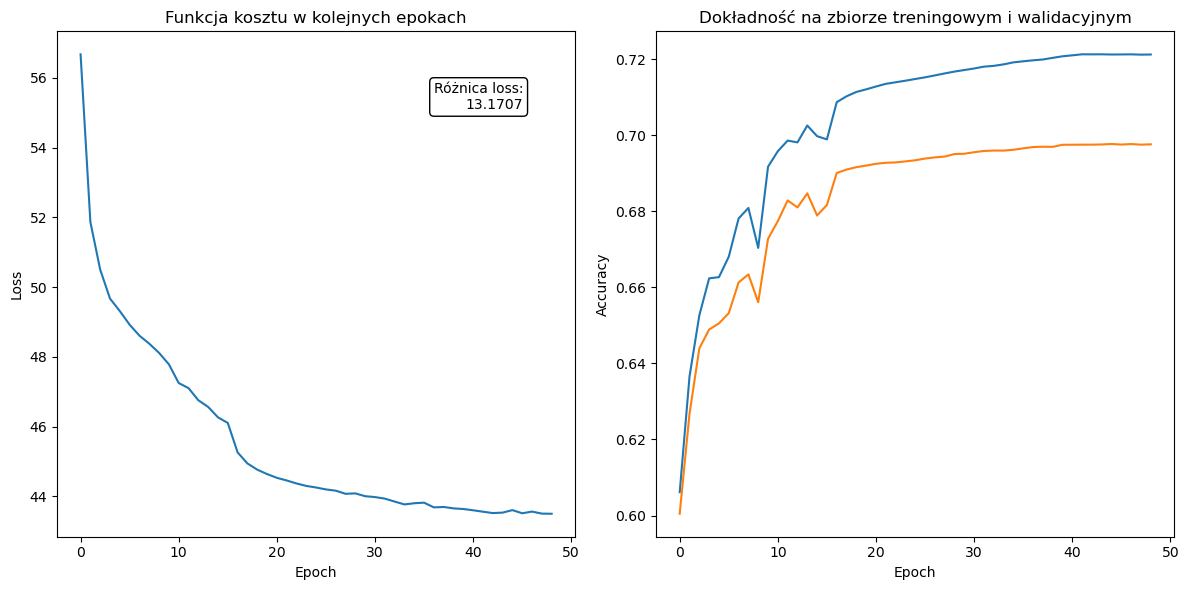

Accuracy test set: 0.6953


In [ ]:
#klasa dla danych
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = texts
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)

#collate_fn do obsługi paddingu i długości
def collate_batch(batch):
    sequences, labels = zip(*batch)

    #sortuje malejąco po długości (wymagane przez pack_padded_sequence)
    seq_lens = [len(seq) for seq in sequences]
    sorted_indices = sorted(range(len(seq_lens)), key=lambda i: -seq_lens[i])
    sequences = [sequences[i] for i in sorted_indices]
    labels = torch.tensor([labels[i] for i in sorted_indices])

    #paduje sekwencje do najdłuższej
    padded_seqs = pad_sequence(sequences, batch_first=True)  
    lengths = torch.tensor([len(seq) for seq in sequences])  # rzeczywiste długości

    return padded_seqs, lengths, labels

#DataLoader z naszym collate_fn i do obsługi batcha
loader = DataLoader(dataset, batch_size=7000, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=7000, shuffle=False, collate_fn=collate_batch)

class Klasyfikator_LSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes, dropout_prob=0.9):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size) #normalizacja warstwy
        self.dropout = nn.Dropout(dropout_prob)  #dodany dropout
        self.bn = nn.BatchNorm1d(hidden_size)    #normalizaca batch
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_input = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_output, (hn, cn) = self.lstm(packed_input)
        last_hidden = hn[-1]
        normed = self.norm(last_hidden) #zastosowanie normalizacji warstwy
        dropped = self.dropout(normed)  #zastosowanie dropout
        bnormed = self.bn(dropped) #zastosowanie normalizacji batcha
        output = self.fc(bnormed)
        return output
    
embedding_dim = 50
hidden_size = 30
num_classes = 3

model = Klasyfikator_LSTM(embedding_dim, hidden_size, num_classes)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.07, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.001)

# Funkcja do oceny dokładności
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, lengths, targets = batch
            outputs = model(inputs, lengths)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

best_val_acc = 0
patience = 4
epochs_no_improve = 0
train_losses = []
val_accuracies = []
train_accuracies = []
print("Rozpoczynam trening")

for epoch in range(50):
    model.train()
    total_loss = 0
    for batch in loader:
        inputs, lengths, targets = batch
        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_accuracy = evaluate_model(model, loader)
    
    #dokładność na zbiorze walidacyjnym
    val_accuracy = evaluate_model(model, val_loader)
    train_losses.append(total_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    scheduler.step(val_accuracy) #scheduler
    #wczesne odciecie
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break
    current_lr =  optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Lr: {current_lr: .2f} | Loss: {total_loss:.3f} | Train acc: {train_accuracy: .4f} | Val acc: {val_accuracy: .4f}")

#wykres loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Funkcja kosztu w kolejnych epokach')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.text(0.90, 0.90, f'Różnica loss:\n{train_losses[0] - train_losses[-1]:.4f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

#wykres accuracy (train, val)
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Dokładność na zbiorze treningowym i walidacyjnym')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

#accuracy zbiór testowy
dataset2 = TextDataset(X_test, y_test)
loader2 = DataLoader(dataset2, batch_size=250, shuffle=True, collate_fn=collate_batch)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader2:
        inputs, lengths, targets = batch
        outputs = model(inputs, lengths)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(targets.tolist())

#dokładnosć
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy test set: {acc:.4f}")

Model 2.

Embedding → LSTM → Layer Norm → Dropout → BatchNorm → Linear

Parametry

    batch_size=7000
    dropout_prob=0.9
    embedding_dim = 50
    hidden_size = 40
    lr=0.7
    weight_decay=0.00001
    scheduler: patience=1, factor=0.5
    early stopping: patience = 5
    epochs = 50

Rozpoczynam trening
Epoch 1 | Lr:  0.07 | Loss: 57.205 | Train acc:  0.6101 | Val acc:  0.6058
Epoch 2 | Lr:  0.07 | Loss: 51.915 | Train acc:  0.6395 | Val acc:  0.6295
Epoch 3 | Lr:  0.07 | Loss: 49.723 | Train acc:  0.6502 | Val acc:  0.6381
Epoch 4 | Lr:  0.07 | Loss: 48.652 | Train acc:  0.6667 | Val acc:  0.6532
Epoch 5 | Lr:  0.07 | Loss: 47.862 | Train acc:  0.6727 | Val acc:  0.6565
Epoch 6 | Lr:  0.07 | Loss: 47.344 | Train acc:  0.6810 | Val acc:  0.6638
Epoch 7 | Lr:  0.07 | Loss: 46.961 | Train acc:  0.6852 | Val acc:  0.6694
Epoch 8 | Lr:  0.07 | Loss: 46.623 | Train acc:  0.6892 | Val acc:  0.6726
Epoch 9 | Lr:  0.07 | Loss: 46.321 | Train acc:  0.6938 | Val acc:  0.6758
Epoch 10 | Lr:  0.07 | Loss: 46.083 | Train acc:  0.7007 | Val acc:  0.6833
Epoch 11 | Lr:  0.07 | Loss: 45.657 | Train acc:  0.7012 | Val acc:  0.6820
Epoch 12 | Lr:  0.04 | Loss: 45.414 | Train acc:  0.6973 | Val acc:  0.6797
Epoch 13 | Lr:  0.04 | Loss: 43.682 | Train acc:  0.7297 | Val acc:  0.7029
E

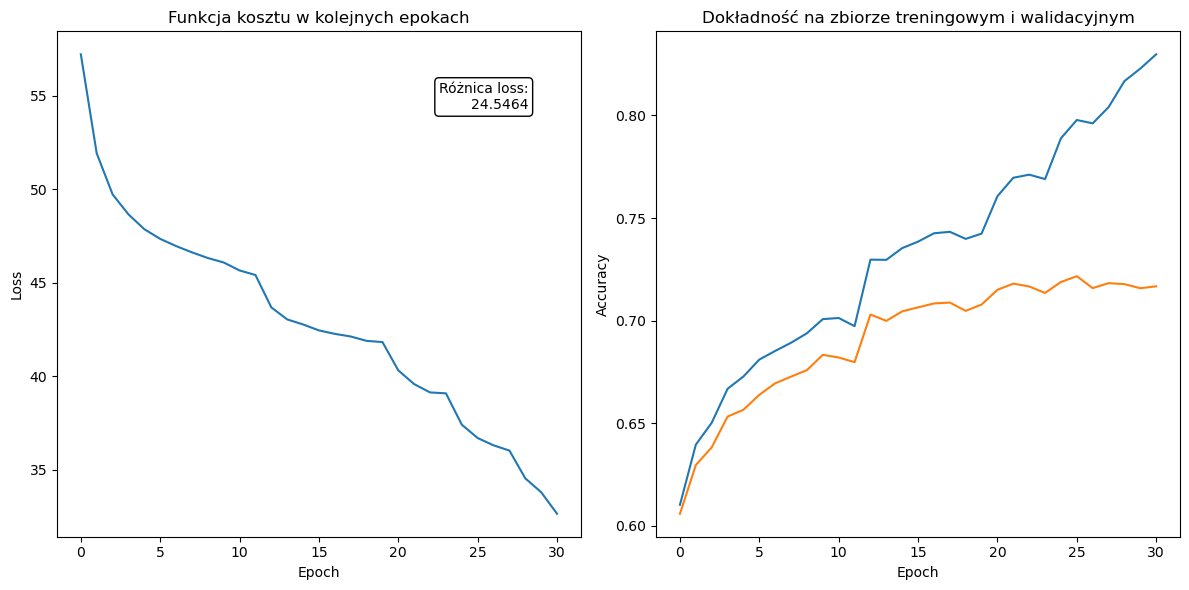

Accuracy test set: 0.7146


In [144]:
#klasa dla danych
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = texts
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)

#collate_fn do obsługi paddingu i długości
def collate_batch(batch):
    sequences, labels = zip(*batch)

    #sortuje malejąco po długości (wymagane przez pack_padded_sequence)
    seq_lens = [len(seq) for seq in sequences]
    sorted_indices = sorted(range(len(seq_lens)), key=lambda i: -seq_lens[i])
    sequences = [sequences[i] for i in sorted_indices]
    labels = torch.tensor([labels[i] for i in sorted_indices])

    #paduje sekwencje do najdłuższej
    padded_seqs = pad_sequence(sequences, batch_first=True)  
    lengths = torch.tensor([len(seq) for seq in sequences])  # rzeczywiste długości

    return padded_seqs, lengths, labels

#DataLoader z naszym collate_fn i do obsługi batcha
loader = DataLoader(dataset, batch_size=7000, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=7000, shuffle=False, collate_fn=collate_batch)

class Klasyfikator_LSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes, dropout_prob=0.9):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size) #normalizacja warstwy
        self.dropout = nn.Dropout(dropout_prob)  #dodany dropout
        self.bn = nn.BatchNorm1d(hidden_size)    #normalizaca batch
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_input = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_output, (hn, cn) = self.lstm(packed_input)
        last_hidden = hn[-1]
        normed = self.norm(last_hidden) #zastosowanie normalizacji warstwy
        dropped = self.dropout(normed)  #zastosowanie dropout
        bnormed = self.bn(dropped) #zastosowanie normalizacji batcha
        output = self.fc(bnormed)
        return output
    
embedding_dim = 50
hidden_size = 40
num_classes = 3

model = Klasyfikator_LSTM(embedding_dim, hidden_size, num_classes)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.07, weight_decay=0.00001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=1, factor=0.5)

# Funkcja do oceny dokładności
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, lengths, targets = batch
            outputs = model(inputs, lengths)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

best_val_acc = 0
patience = 5
epochs_no_improve = 0
train_losses = []
val_accuracies = []
train_accuracies = []
print("Rozpoczynam trening")
for epoch in range(50):
    model.train()
    total_loss = 0
    for batch in loader:
        inputs, lengths, targets = batch
        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_accuracy = evaluate_model(model, loader)
    
    #dokładność na zbiorze walidacyjnym
    val_accuracy = evaluate_model(model, val_loader)
    train_losses.append(total_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    scheduler.step(val_accuracy) #scheduler
    #wczesne odciecie
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break
    current_lr =  optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Lr: {current_lr: .2f} | Loss: {total_loss:.3f} | Train acc: {train_accuracy: .4f} | Val acc: {val_accuracy: .4f}")

#wykres loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Funkcja kosztu w kolejnych epokach')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.text(0.90, 0.90, f'Różnica loss:\n{train_losses[0] - train_losses[-1]:.4f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

#wykres accuracy (train, val)
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Dokładność na zbiorze treningowym i walidacyjnym')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

#accuracy zbiór testowy
dataset2 = TextDataset(X_test, y_test)
loader2 = DataLoader(dataset2, batch_size=250, shuffle=True, collate_fn=collate_batch)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader2:
        inputs, lengths, targets = batch
        outputs = model(inputs, lengths)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(targets.tolist())

#dokładnosć
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy test set: {acc:.4f}")

Model 3.

Embedding → LSTM → Dropout → BatchNorm → ReLU → Linear

Parametry

    batch_size=1000
    dropout_prob=0.8
    embedding_dim = 100
    hidden_size = 10
    lr=0.001
    scheduler:  patience=3, factor=0.7
    early stopping: patience = 4
    epochs = 30

Rozpoczynam trening
Epoch 1 | Lr:  0.00100 | Loss: 418.919 | Train acc:  0.4350 | Val acc:  0.4378
Epoch 2 | Lr:  0.00100 | Loss: 401.847 | Train acc:  0.5602 | Val acc:  0.5574
Epoch 3 | Lr:  0.00100 | Loss: 388.938 | Train acc:  0.6111 | Val acc:  0.6027
Epoch 4 | Lr:  0.00100 | Loss: 380.616 | Train acc:  0.6279 | Val acc:  0.6168
Epoch 5 | Lr:  0.00100 | Loss: 373.372 | Train acc:  0.6511 | Val acc:  0.6329
Epoch 6 | Lr:  0.00100 | Loss: 368.187 | Train acc:  0.6582 | Val acc:  0.6350
Epoch 7 | Lr:  0.00100 | Loss: 364.732 | Train acc:  0.6656 | Val acc:  0.6374
Epoch 8 | Lr:  0.00100 | Loss: 361.688 | Train acc:  0.6770 | Val acc:  0.6434
Epoch 9 | Lr:  0.00100 | Loss: 358.300 | Train acc:  0.6816 | Val acc:  0.6424
Epoch 10 | Lr:  0.00100 | Loss: 355.689 | Train acc:  0.6867 | Val acc:  0.6450
Epoch 11 | Lr:  0.00100 | Loss: 353.823 | Train acc:  0.6904 | Val acc:  0.6452
Epoch 12 | Lr:  0.00100 | Loss: 351.736 | Train acc:  0.6904 | Val acc:  0.6416
Epoch 13 | Lr:  0.00100 | Los

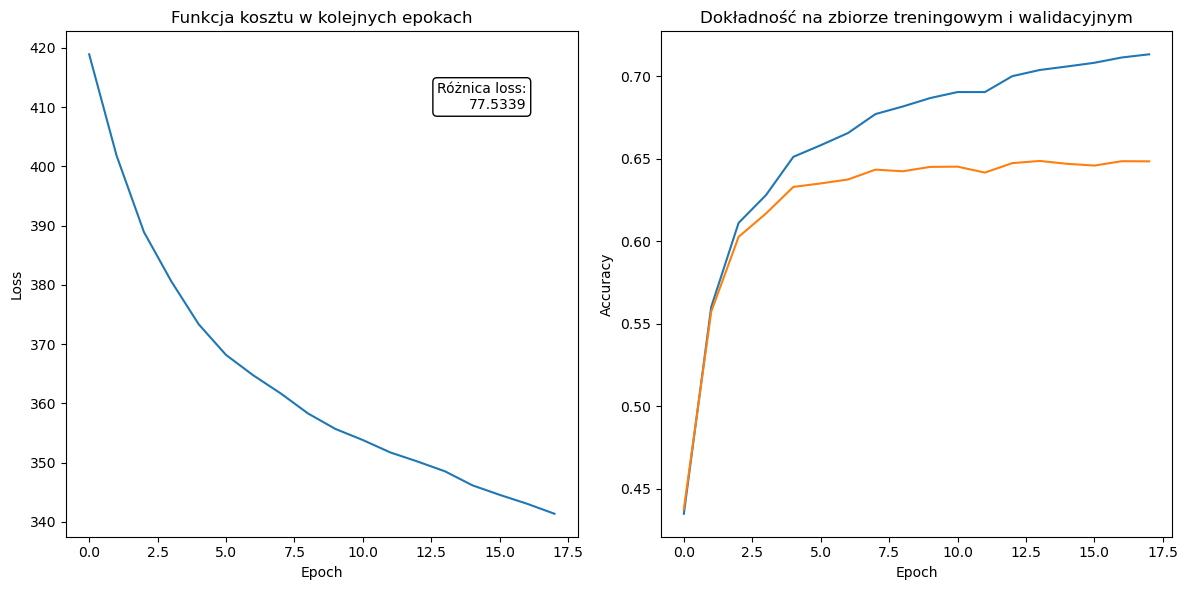

Accuracy test set: 0.6462


In [55]:
#klasa dla danych
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = texts
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)

#collate_fn do obsługi paddingu i długości
def collate_batch(batch):
    sequences, labels = zip(*batch)

    #sortuje malejąco po długości (wymagane przez pack_padded_sequence)
    seq_lens = [len(seq) for seq in sequences]
    sorted_indices = sorted(range(len(seq_lens)), key=lambda i: -seq_lens[i])
    sequences = [sequences[i] for i in sorted_indices]
    labels = torch.tensor([labels[i] for i in sorted_indices])

    #paduje sekwencje do najdłuższej
    padded_seqs = pad_sequence(sequences, batch_first=True)  
    lengths = torch.tensor([len(seq) for seq in sequences])  # rzeczywiste długości

    return padded_seqs, lengths, labels

#DataLoader z naszym collate_fn i do obsługi batcha
loader = DataLoader(dataset, batch_size=1000, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False, collate_fn=collate_batch)

class Klasyfikator_LSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes, dropout_prob=0.8):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)  #dodany dropout
        self.bn = nn.BatchNorm1d(hidden_size)    #normalizaca batch
        self.relu = nn.ReLU()                        # dodana aktywacja ReLU
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_input = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_output, (hn, cn) = self.lstm(packed_input)
        last_hidden = hn[-1]
        dropped = self.dropout(last_hidden)  #zastosowanie dropout
        bnormed = self.bn(dropped)                   # normalizacja batch
        activated = self.relu(bnormed)               # ReLU
        output = self.fc(activated)                  # warstwa liniowa
        return output
    
embedding_dim = 100
hidden_size = 10
num_classes = 3

model = Klasyfikator_LSTM(embedding_dim, hidden_size, num_classes)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #usuwam weight_decay=0.00001 bo batch normalizacja
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.7)

# Funkcja do oceny dokładności
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, lengths, targets = batch
            outputs = model(inputs, lengths)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

best_val_acc = 0
patience = 4
epochs_no_improve = 0
train_losses = []
val_accuracies = []
train_accuracies = []
print("Rozpoczynam trening")
for epoch in range(30):
    model.train()
    total_loss = 0
    for batch in loader:
        inputs, lengths, targets = batch
        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_accuracy = evaluate_model(model, loader)
    
    #dokładność na zbiorze walidacyjnym
    val_accuracy = evaluate_model(model, val_loader)
    train_losses.append(total_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    scheduler.step(val_accuracy) #scheduler
    #wczesne odciecie
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break
    current_lr =  optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Lr: {current_lr: .5f} | Loss: {total_loss:.3f} | Train acc: {train_accuracy: .4f} | Val acc: {val_accuracy: .4f}")

#wykres loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Funkcja kosztu w kolejnych epokach')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.text(0.90, 0.90, f'Różnica loss:\n{train_losses[0] - train_losses[-1]:.4f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

#wykres accuracy (train, val)
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Dokładność na zbiorze treningowym i walidacyjnym')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

#accuracy zbiór testowy
dataset2 = TextDataset(X_test, y_test)
loader2 = DataLoader(dataset2, batch_size=250, shuffle=True, collate_fn=collate_batch)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader2:
        inputs, lengths, targets = batch
        outputs = model(inputs, lengths)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(targets.tolist())

#dokładnosć
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy test set: {acc:.4f}")

Model 4. (zaczełam liczyć jeszcze taki model ale nie zapowiadał się dobrze)

Embedding → LSTM → LayerNorm → Dropout → ReLU → Linear

Parametry

    batch_size=1000
    dropout_prob=0.8
    embedding_dim = 100
    hidden_size = 10
    lr=0.001
    weight_decay=0.0001
    scheduler:  patience=3, factor=0.7
    early stopping: patience = 3
    epochs = 30

In [56]:
#klasa dla danych
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.data = texts
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)

#collate_fn do obsługi paddingu i długości
def collate_batch(batch):
    sequences, labels = zip(*batch)

    #sortuje malejąco po długości (wymagane przez pack_padded_sequence)
    seq_lens = [len(seq) for seq in sequences]
    sorted_indices = sorted(range(len(seq_lens)), key=lambda i: -seq_lens[i])
    sequences = [sequences[i] for i in sorted_indices]
    labels = torch.tensor([labels[i] for i in sorted_indices])

    #paduje sekwencje do najdłuższej
    padded_seqs = pad_sequence(sequences, batch_first=True)  
    lengths = torch.tensor([len(seq) for seq in sequences])  # rzeczywiste długości

    return padded_seqs, lengths, labels

#DataLoader z naszym collate_fn i do obsługi batcha
loader = DataLoader(dataset, batch_size=1000, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_dataset, batch_size=1000, shuffle=False, collate_fn=collate_batch)

class Klasyfikator_LSTM(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes, dropout_prob=0.8):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.norm = nn.LayerNorm(hidden_size) #normalizacja warstwy
        self.dropout = nn.Dropout(dropout_prob)  #dodany dropout
        self.relu = nn.ReLU()                        # dodana aktywacja ReLU
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        packed_input = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_output, (hn, cn) = self.lstm(packed_input)
        last_hidden = hn[-1]
        normed = self.norm(last_hidden) #zastosowanie normalizacji warstwy
        dropped = self.dropout(normed)  #zastosowanie dropout
        activated = self.relu(dropped)               # ReLU
        output = self.fc(activated)                  # warstwa liniowa
        return output
    
embedding_dim = 100
hidden_size = 15
num_classes = 3

model = Klasyfikator_LSTM(embedding_dim, hidden_size, num_classes)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,  weight_decay=0.0001) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.7)

# Funkcja do oceny dokładności
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            inputs, lengths, targets = batch
            outputs = model(inputs, lengths)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

best_val_acc = 0
patience = 3
epochs_no_improve = 0
train_losses = []
val_accuracies = []
train_accuracies = []
print("Rozpoczynam trening")
for epoch in range(30):
    model.train()
    total_loss = 0
    for batch in loader:
        inputs, lengths, targets = batch
        optimizer.zero_grad()
        outputs = model(inputs, lengths)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_accuracy = evaluate_model(model, loader)
    
    #dokładność na zbiorze walidacyjnym
    val_accuracy = evaluate_model(model, val_loader)
    train_losses.append(total_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    scheduler.step(val_accuracy) #scheduler
    #wczesne odciecie
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping!")
            break
    current_lr =  optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1} | Lr: {current_lr: .5f} | Loss: {total_loss:.3f} | Train acc: {train_accuracy: .4f} | Val acc: {val_accuracy: .4f}")

#wykres loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss')
plt.title('Funkcja kosztu w kolejnych epokach')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.text(0.90, 0.90, f'Różnica loss:\n{train_losses[0] - train_losses[-1]:.4f}', 
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

#wykres accuracy (train, val)
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Dokładność na zbiorze treningowym i walidacyjnym')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

#accuracy zbiór testowy
dataset2 = TextDataset(X_test, y_test)
loader2 = DataLoader(dataset2, batch_size=250, shuffle=True, collate_fn=collate_batch)

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in loader2:
        inputs, lengths, targets = batch
        outputs = model(inputs, lengths)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.tolist())
        all_labels.extend(targets.tolist())

#dokładnosć
acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy test set: {acc:.4f}")

Rozpoczynam trening
Epoch 1 | Lr:  0.00100 | Loss: 405.205 | Train acc:  0.6277 | Val acc:  0.6134
Epoch 2 | Lr:  0.00100 | Loss: 376.120 | Train acc:  0.6484 | Val acc:  0.6305
Epoch 3 | Lr:  0.00100 | Loss: 368.760 | Train acc:  0.6588 | Val acc:  0.6415
Epoch 4 | Lr:  0.00100 | Loss: 365.775 | Train acc:  0.6557 | Val acc:  0.6381
Epoch 5 | Lr:  0.00100 | Loss: 363.567 | Train acc:  0.6623 | Val acc:  0.6465


KeyboardInterrupt: 

<h4> Zadanie2 (2 pkt): Wybierz co najmniej 3 kandydatów na prezydenta. Stwórz zbiór co najmniej 100 wypowiedzi na osobę, a następnie zbuduj klasyfikator na bazie istniejącego modelu - w oparciu o wypowiedź tekst przewiduje który kandydat mógł to powiedzieć.
    
    
Uwagi i wskazówki:
- możesz oprzeć się na modelu herbert-base-cased 
- pobieranie wypowiedzi warto (chociaż częsciowo) zrealizować w sposób automatyczny (np. selenium)
- może warto wybrać wypowiedzi z debat, poszukaj wtedy odpowiednich bibliotek w python do pobierania napisów z youtube; w przypadku dłuższych wypowiedzi podziel je na krótsze -> nawet jedno zdanie
- zadbaj o jakość danych! Pamiętaj, że to jest podstawa sukcesu! (dobre dane + dobry model = sukces, słabe dane + dowolony model = porażka). Usuń ewentualne duplikaty. W przypadku tweetów rozważ czy warto uwzględnić także przekierowania
- podziel dane na zbiór trenignowy/walidacyjny/testowy (7:2:1); wyznacz dokładności na tych zbiorach
- sprawdz bezpośrednio model na przykładowych wypowiedziach 
- (opcjonalnie) może warto rozbudować część klasyfikacyjną, poszukaj jak to zrobić

In [40]:
from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizer, BertModel
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
import sacremoses

tokenizer = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
model = AutoModelForSequenceClassification.from_pretrained("allegro/herbert-base-cased", num_labels=4)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at allegro/herbert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
with open('mentzen.txt', 'r') as file:
    men = file.read().replace('\n', ' ')
with open('senyszyn.txt', 'r') as file:
    sen = file.read().replace('\n', ' ')
with open('nawrocki.txt', 'r') as file:
    naw = file.read().replace('\n', ' ')
with open('trzaskowski.txt', 'r') as file:
    trz = file.read().replace('\n', ' ')

size =406
men = men.split('.'); men =[x for x in men if x!=''][:size]
sen = sen.split('.'); sen =[x for x in sen if x!=''][:size]
naw = naw.split('.'); naw =[x for x in naw if x!=''][:size]
trz = trz.split('.'); trz =[x for x in trz if x!=''][:size]

print(len(men), len(sen), len(naw), len(trz))

text = men + naw + sen + trz
labels = [0]*len(men) + [1]*len(naw) + [2]*len(sen) + [3]*len(trz)
from sklearn.model_selection import train_test_split

#trenignowy/walidacyjny/testowy (7:2:1); 

X_train, X_temp, y_train, y_temp = train_test_split(text, labels, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

encodings = tokenizer(X_train, truncation=True, padding=True)
val_encodings = tokenizer(X_val, truncation=True, padding=True)

406 406 406 406


In [48]:
import torch

class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

dataset = TextDataset(encodings, y_train)
val_dataset = TextDataset(val_encodings, y_val)

from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results", #gdzie zapisze model
    num_train_epochs=3,  #liczba epok
    per_device_train_batch_size=4, #rozmiar batcha
    logging_dir="./logs", #gdzie zapisze logi (dane z treningu)
    logging_steps=100,  #co ile batchow zapisac logi ->> mozna na bieżaco sprawdzac jak model sie uczy
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset, #mozna tez dorzucic zbior walidacyjny eval_dataset=val_dataset,
    eval_dataset=val_dataset
)

trainer.train()

Step,Training Loss
100,0.410000
200,0.256500
300,0.208500
400,0.082500
500,0.139100
600,0.072000
700,0.005700
800,0.060500


TrainOutput(global_step=852, training_loss=0.15018766894586769, metrics={'train_runtime': 2560.1976, 'train_samples_per_second': 1.331, 'train_steps_per_second': 0.333, 'total_flos': 201406907295360.0, 'train_loss': 0.15018766894586769, 'epoch': 3.0})

In [49]:
from sklearn.metrics import accuracy_score
def get_acc(X, y):
    #model.eval()
    preds = []

    with torch.no_grad():
        for text in X:
            inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True)
            outputs = model(**inputs)
            pred = torch.argmax(outputs.logits, dim=1).item()
            preds.append(pred)
    acc = accuracy_score(y, preds)
    return acc
print(f'Train set accuracy: {get_acc(X_train, y_train)}')
print(f'Test set accuracy: {get_acc(X_test, y_test)}')
print(f'Val set accuracy: {get_acc(X_val, y_val)}')

Train set accuracy: 0.9894366197183099
Test set accuracy: 0.6861538461538461
Val set accuracy: 0.7300613496932515


In [ ]:
import random as rd
n = rd.randint(0,len(X_test))

słownik = {0: 'Mentzen', 1: 'Nawrocki', 2:'Senyszyn', 3: 'Trzaskowski'}
model.eval()
with torch.no_grad():
    inputs = tokenizer(X_test[n], return_tensors='pt', padding=True, truncation=True)
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    print(f'Zdanie: {X_test[n]} \nPrediction: {słownik.get(pred)} \nTrue label: {słownik.get(y_test[n])}')

Zdanie:  Ciekawe, ile razy rżnięty i przez kogo? Kretynizm postępuje 
Prediction: Senyszyn 
True label: Senyszyn
